# Sliding-p time-data analysis

This notebook loads the per-initial-condition CSV files produced by the matching time-data Julia script.


In [1]:
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("default")
plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 16,
})


def float_str(f):
    return str(float(f)).replace(".", "p")


In [2]:
# These controls mirror get_time_random_slidding_p_time_data.jl.
L_vals = [35000]
upper_val = 0.43
lower_div = 20
lower_val = round(upper_val / lower_div, ndigits=6)
p_c = 0.47882
p_rate = 0.0002
p_vals = sorted(set([round(p_c + i * p_rate, 6) for i in range(-2, 3)]))
# p_vals = sorted(set([round(0.4928 + i * 0.0005, 6) for i in range(-3, 3)] + [round(0.49275 + i * 0.00005, 6) for i in range(-3, 3)] + [round(p_c + i * p_rate, 6) for i in range(-3, 4)]))
# p_vals = sorted(set([round(p_c + i * p_rate, 6) for i in range(-3, 4)] + [0.4918, 0.4923, 0.4933, 0.4938]))
upper_epsilons = [upper_val] * len(p_vals)
lower_epsilons = [lower_val] * len(p_vals)

control_vals = sorted(p_vals)
control_label = r"$p$"
model_label = r"Time-Random Sliding $p$"
time_prefact = 100
time_step = 2000
num_initial_conds = 20000
num_init_conds_offset = 0
initial_state_prob = 0.5
DATA_ROOT = Path("data/time_rand_slidding_p/rho_per_time/IC1")
DATA_ROOT = Path("/Volumes/ExternalData/stavskya_mc/data/time_rand_slidding_p/rho_per_time/IC1")
FIG_ROOT = Path("figs/time_random/slidding_p")
FIG_ROOT.mkdir(parents=True, exist_ok=True)


def sample_path(L_val, upper_ep, lower_ep, p_val, init_cond):
    upper_name, lower_name, p_name = map(float_str, (upper_ep, lower_ep, p_val))
    return DATA_ROOT / f"L{L_val}" / f"epsilonu{upper_name}" / f"epsilonl{lower_name}" / f"pval{p_name}" / (
        f"IC1_L{L_val}_epsilonu{upper_name}_epsilonl{lower_name}_pval{p_name}_"
        f"timepref{time_prefact}_timestep{time_step}_sample{init_cond}.csv"
    )


In [3]:
list(zip(control_vals, upper_epsilons, lower_epsilons, p_vals))

[(0.47842, 0.43, 0.0215, 0.47842),
 (0.47862, 0.43, 0.0215, 0.47862),
 (0.47882, 0.43, 0.0215, 0.47882),
 (0.47902, 0.43, 0.0215, 0.47902),
 (0.47922, 0.43, 0.0215, 0.47922)]

In [ ]:
# Load every available initial-condition trajectory and calculate mean and SEM.
mean_rhos = {}
sem_rhos = {}
time_vals = {}
loaded_counts = {}

for L_val in L_vals:
    for control_val, upper_ep, lower_ep in zip(control_vals, upper_epsilons, lower_epsilons):
        print(f"p = {control_val}")
        trajectories = []
        times = None
        for init_cond in range(1 + num_init_conds_offset, num_initial_conds + 1 + num_init_conds_offset):
            filepath = sample_path(L_val, upper_ep, lower_ep, control_val, init_cond)
            if init_cond == 1:
                print(filepath)
            if not filepath.exists():
                continue
            sample_df = pd.read_csv(filepath)
            if times is None:
                times = sample_df["time"].to_numpy()
            trajectories.append(sample_df["rho"].to_numpy())
        if not trajectories:
            raise FileNotFoundError(f"No trajectories found for L={L_val}, {control_label}={control_val}")
        trajectories = np.asarray(trajectories)
        key = (L_val, control_val)
        time_vals[key] = times
        mean_rhos[key] = trajectories.mean(axis=0)
        sem_rhos[key] = trajectories.std(axis=0, ddof=1) / np.sqrt(len(trajectories))
        loaded_counts[key] = len(trajectories)

loaded_counts


p = 0.47842
/Volumes/ExternalData/stavskya_mc/data/time_rand_slidding_p/rho_per_time/IC1/L35000/epsilonu0p43/epsilonl0p0215/pval0p47842/IC1_L35000_epsilonu0p43_epsilonl0p0215_pval0p47842_timepref100_timestep2000_sample1.csv


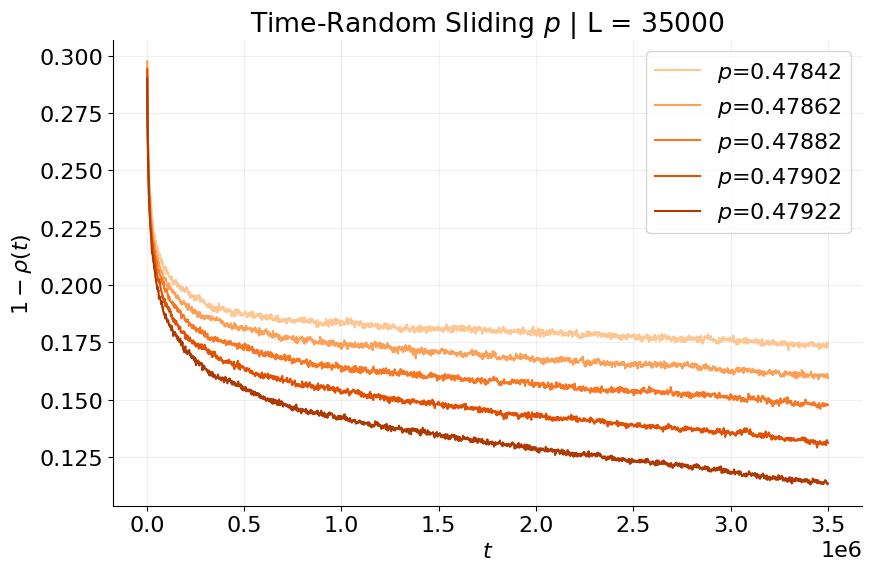

In [ ]:

for L_val in L_vals:
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.colormaps.get_cmap("Oranges").resampled(len(control_vals) + 3)
    for i, control_val in enumerate(control_vals):
        key = (L_val, control_val)
        ax.plot(time_vals[key], 1 - mean_rhos[key], color=cmap(i + 2), label=fr"{control_label}={control_val}")
    ax.set_title(model_label + f" | L = {L_val}")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$1 - \rho(t)$")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_ROOT / f"rho_per_timeL{L_val}.png", dpi=200)
    plt.show()


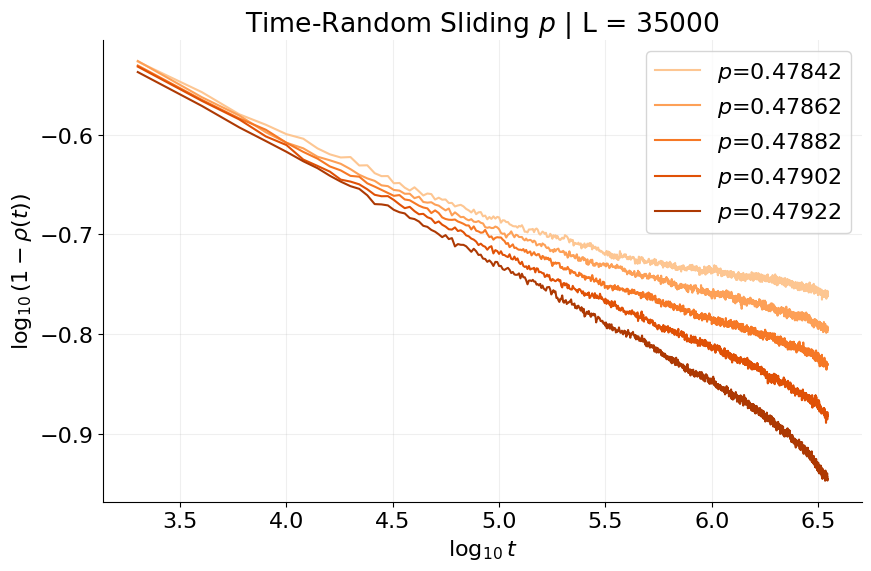

In [ ]:

for L_val in L_vals:
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.colormaps.get_cmap("Oranges").resampled(len(control_vals) + 3)
    for i, control_val in enumerate(control_vals):
        key = (L_val, control_val)
        positive = (time_vals[key] > 0) & (1 - mean_rhos[key] > 0)
        ax.plot(np.log10(time_vals[key][positive]), np.log10((1 - mean_rhos[key])[positive]),
                color=cmap(i + 2), label=fr"{control_label}={control_val}")
    ax.set_title(model_label + f" | L = {L_val}")
    ax.set_xlabel(r"$\log_{10} t$")
    ax.set_ylabel(r"$\log_{10}(1 - \rho(t))$")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_ROOT / f"rho_per_time_logL{L_val}.png", dpi=200)
    plt.show()


In [ ]:
def log_b(x, b):
    return np.log(x) / np.log(b)

In [ ]:
control_vals

[0.47805, 0.47835, 0.47865, 0.47895, 0.47925, 0.47955, 0.47985]

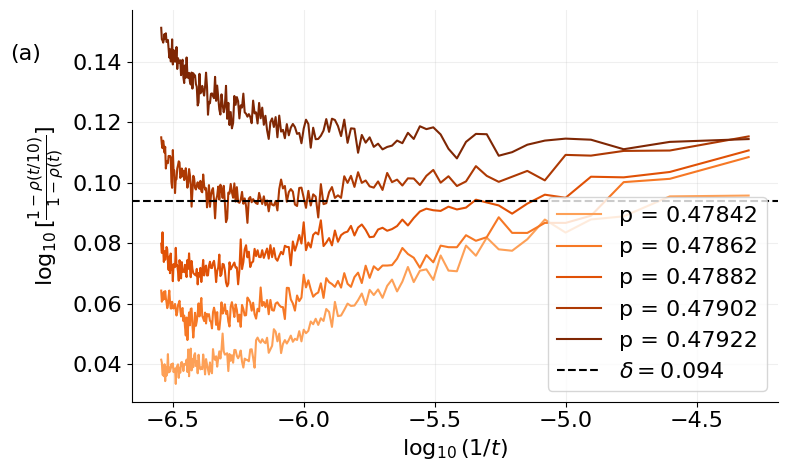

In [ ]:
b = 10
delta_guess = 0.094
for j, L in enumerate(L_vals):
    fig=plt.figure(figsize=(8,5))
    for i, control_val in enumerate(control_vals):
        # if control_val in [0.492975, 0.49295, 0.492925, 0.492875, 0.49285, 0.492825]:
            # continue
        c = cmap(i+3)
        key = (L, control_val)
        l_time_vals = [t * b for t in time_vals[key] if t*b <=max(time_vals[key])]
        data_to_plot = 1 - mean_rhos[key]
        data_to_plot_numerator = np.array([data_to_plot[(t//(b*time_step)) -1] for t in l_time_vals])
        data_to_plot_denomenator = np.array([data_to_plot[((t)//time_step) -1] for t in l_time_vals])
        ok = (data_to_plot_numerator > 0) & (data_to_plot_denomenator > 0)   # 2026-09: only times with Q(t/b), Q(t) > 0 (no log of 0)
        l_time_vals = np.array(l_time_vals)[ok]
        data_to_plot = log_b(data_to_plot_numerator[ok]/data_to_plot_denomenator[ok], 10)
        plt.plot(
            log_b((1/np.array(l_time_vals)), b), 
            data_to_plot, 
            label = fr"p = {control_val}",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    
    
    plt.axhline(delta_guess, c = 'k', label=fr"$\delta = {delta_guess}$", linestyle ="--")
    # plt.title(fr"Time Random: $L = {L}$ $\|$ $a = {a_val}$")
    plt.text(0.01, 0.85, "(a)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    plt.xlabel(r"$\log_{10}(1/t)$")
    plt.ylabel(r"$\log_{10}[\frac{1-\rho(t/10)}{1-\rho(t)}]$")
    plt.legend()
    # plt.xlim((np.log(0.000005), np.log(0.0005)))
    # plt.ylim((0.01, 0.25))
    plt.tight_layout()
    # plt.savefig(f"figs/time_random/broad/broadstav_determining_ac_delta.png")
    plt.show()

Beta: 0.235


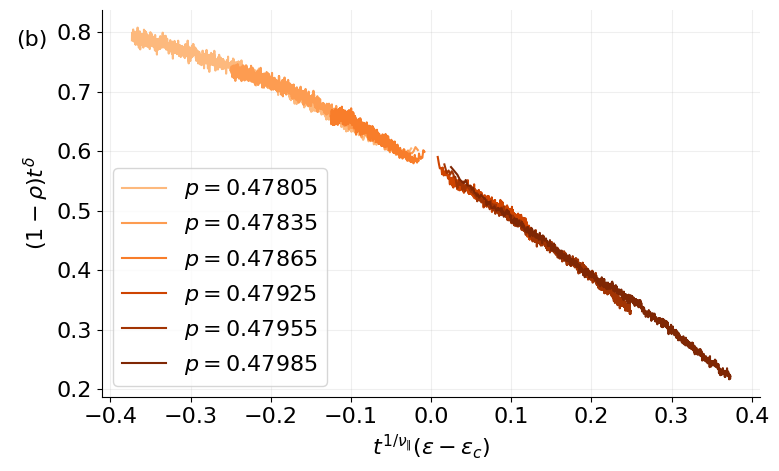

In [ ]:
delta_guess = 0.094
guess_nu_par = 2.5
control_c = 0.47895
# control_vals = [0.4938, 0.4933, 0.4913, 0.4918]
print(f"Beta: {delta_guess*guess_nu_par}")
for j, L in enumerate(L_vals):
    plt.figure(figsize=(8,5))
    for i, control_val in enumerate(control_vals):
        if control_val == control_c:
            continue
        c = cmap(i+3)
        key = (L, control_val)
        l_time_vals = np.array([t for t in time_vals[key]])
        orig_data = (1 - mean_rhos[key])
        plt.plot(
            (l_time_vals**(1/guess_nu_par)*(control_val - control_c))[1:], 
            (orig_data * l_time_vals ** delta_guess)[1:], 
            label = fr"$p = {control_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    # plt.title(fr"Time Random $a = {a_val}$: $L = {L}$ $\|$ $\delta = {delta_guess}$ $\|$ $\nu_{{\|}} = {guess_nu_par}$")
    plt.text(0.02, 0.85, "(b)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    plt.xlabel(r"$t^{1/\nu_{\|}}(p - p_c)$")
    plt.ylabel(r"$(1 - \rho)t^\delta$")
    plt.legend()
    # plt.xlim(0.0003, 0.16)
    # plt.ylim(0.3, 1.1)

    plt.tight_layout()
    # plt.savefig(f"figs/time_random/broad/broadstav_determining_nupar.png")
    plt.show()

In [ ]:
[round(0.49275 + i * 0.00005, 6) for i in range(-3, 4)]

[0.4926, 0.49265, 0.4927, 0.49275, 0.4928, 0.49285, 0.4929]

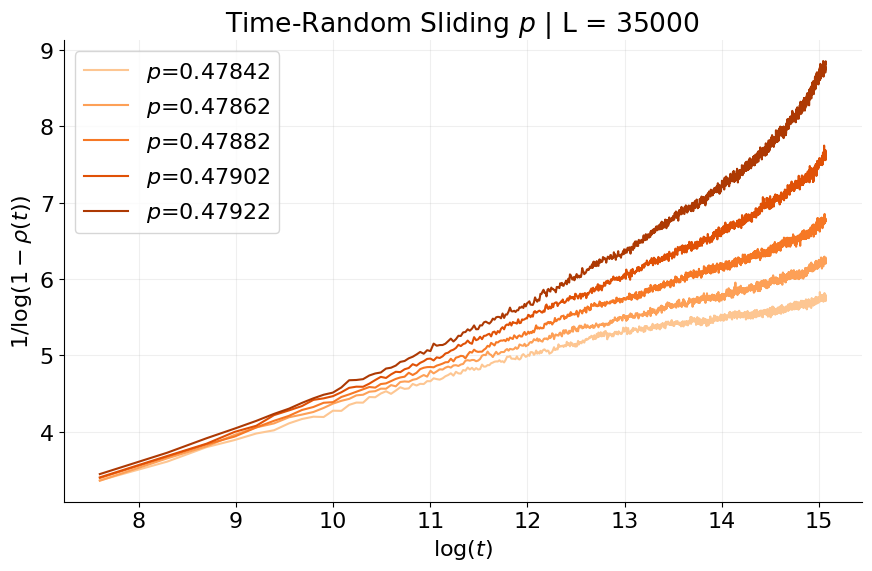

In [ ]:
for L_val in L_vals:
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.colormaps.get_cmap("Oranges").resampled(len(control_vals) + 3)
    for i, control_val in enumerate(control_vals):
        key = (L_val, control_val)
        positive = (time_vals[key] > 0) & (1 - mean_rhos[key] > 0)
        ax.plot(np.log(time_vals[key][positive]), 1/((1 - mean_rhos[key]))[positive],
                color=cmap(i + 2), label=fr"{control_label}={control_val}")
    ax.set_title(model_label + f" | L = {L_val}")
    ax.set_xlabel(r"$\log (t)$")
    ax.set_ylabel(r"$1/(1 - \rho(t))$")
    ax.legend()
    fig.tight_layout()
    # fig.savefig(FIG_ROOT / f"rho_per_time_logL{L_val}.png", dpi=200)
    plt.show()

alpha = 0.9970323149353885


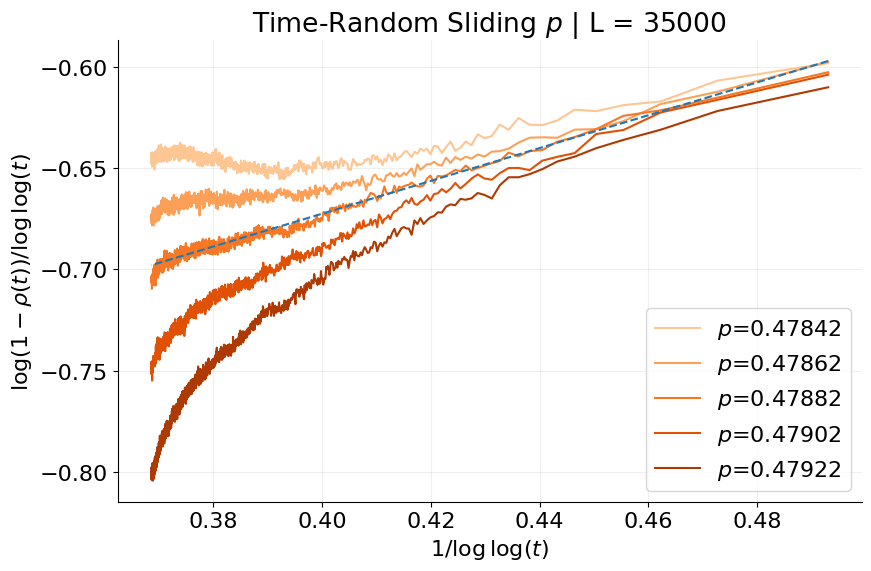

In [ ]:
control_c = 0.47882
for L_val in L_vals:
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.colormaps.get_cmap("Oranges").resampled(len(control_vals) + 3)
    for i, control_val in enumerate(control_vals):
        key = (L_val, control_val)
        positive = (time_vals[key] > 0) & (1 - mean_rhos[key] > 0)
        X = 1/np.log(np.log(time_vals[key][positive]))
        ax.plot(X, np.log(((1 - mean_rhos[key]))[positive])*X,
                color=cmap(i + 2), label=fr"{control_label}={control_val}")
    crit_key = (L_val, control_c)
    positive = (time_vals[crit_key] > 0) & (1 - mean_rhos[crit_key] > 0)   # mask for crit_key itself
    X = 1/np.log(np.log(time_vals[crit_key][positive]))
    m,b = np.polyfit(X[0:100], (np.log(((1 - mean_rhos[crit_key]))[positive])*X)[0:100], 1)
    ax.plot(X, m * X + b, linestyle="--")
    print(f"alpha = {-b}")
    ax.set_title(model_label + f" | L = {L_val}")
    ax.set_xlabel(r"$1/\log \log (t)$")
    ax.set_ylabel(r"$\log(1 - \rho(t))/\log \log (t)$")
    ax.legend()
    fig.tight_layout()
    # fig.savefig(FIG_ROOT / f"rho_per_time_logL{L_val}.png", dpi=200)
    plt.show()

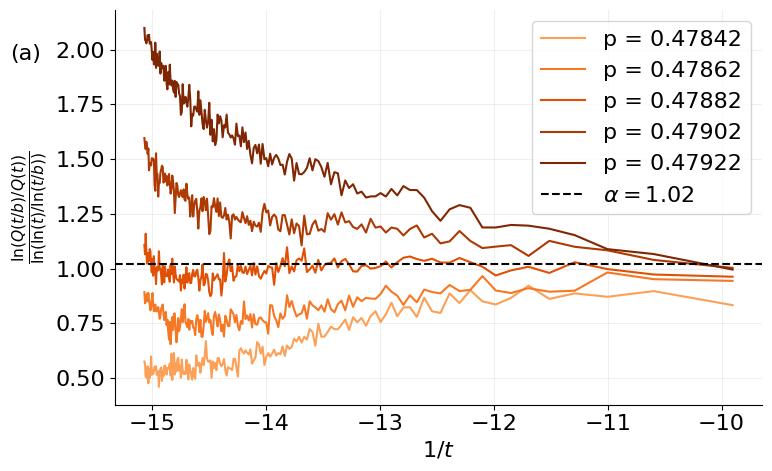

In [ ]:
b = 10
alpha_guess = 1.02
for j, L in enumerate(L_vals):
    fig=plt.figure(figsize=(8,5))
    for i, control_val in enumerate(control_vals):
        if control_val in [0.47895]:
            continue
        c = cmap(i+3)
        key = (L, control_val)
        l_time_vals = [t * b for t in time_vals[key] if t*b <=max(time_vals[key])]
        data_to_plot = 1 - mean_rhos[key]
        data_to_plot_numerator1 = np.array([data_to_plot[(t//(b*time_step)) -1] for t in l_time_vals])
        data_to_plot_numerator2 = np.array([data_to_plot[(t//(time_step)) - 1] for t in l_time_vals])
        data_to_plot_denomenator1 = np.log(np.array(l_time_vals))
        data_to_plot_denomenator2 = np.log(np.array(l_time_vals)//b)
        ok = (data_to_plot_numerator1 > 0) & (data_to_plot_numerator2 > 0)   # 2026-09: only times with Q(t/b), Q(t) > 0 (no log of 0)
        l_time_vals = np.array(l_time_vals)[ok]
        data_to_plot = np.log(data_to_plot_numerator1[ok]/data_to_plot_numerator2[ok]) / np.log(data_to_plot_denomenator1[ok]/data_to_plot_denomenator2[ok])
        plt.plot(
            np.log(1/np.array(l_time_vals)), 
            data_to_plot, 
            label = fr"p = {control_val}",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    
    
    plt.axhline(alpha_guess, c = 'k', label=fr"$\alpha = {alpha_guess}$", linestyle ="--")
    # plt.title(fr"Time Random: $L = {L}$ $\|$ $a = {a_val}$")
    plt.text(0.03, 0.85, "(a)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    plt.xlabel(r"$\ln(1/t)$")
    plt.ylabel(r"$\frac{\ln(Q(t/b)/Q(t))}{\ln(\ln(t)/\ln(t/b))}$")
    plt.legend()
    # plt.xlim((np.log(0.000005), np.log(0.0005)))
    # plt.ylim((0.01, 0.25))
    plt.tight_layout()
    # plt.savefig(f"figs/time_random/broad/broadstav_determining_ac_delta.png")
    plt.show()

Beta: 0.21


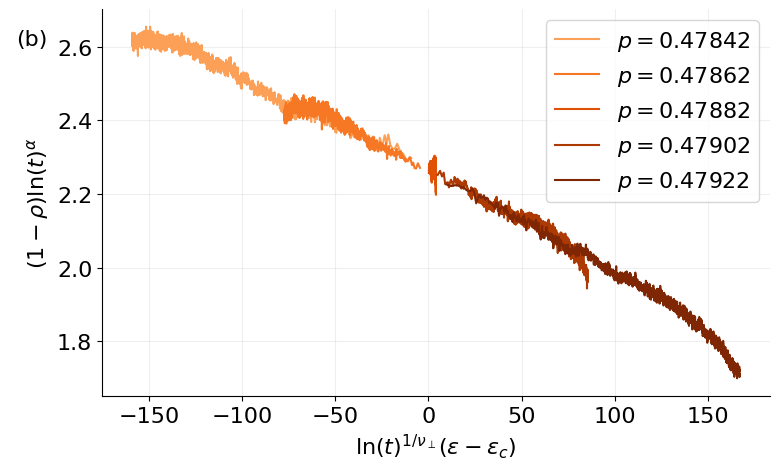

In [ ]:
alpha_guess = 1.0
guess_nu_perp = 0.21
control_c = 0.47881
# control_vals = [0.4938, 0.4933, 0.4913, 0.4918]
print(f"Beta: {alpha_guess*guess_nu_perp}")
for j, L in enumerate(L_vals):
    plt.figure(figsize=(8,5))
    for i, control_val in enumerate(control_vals):
        if control_val == control_c or i == 6:
            continue
        c = cmap(i+3)
        key = (L, control_val)
        l_time_vals = np.array([t for t in time_vals[key]])
        orig_data = (1 - mean_rhos[key])
        plt.plot(
            (np.log(l_time_vals)**(1/guess_nu_perp)*(control_val - control_c))[1:], 
            (orig_data * np.log(l_time_vals) ** alpha_guess)[1:], 
            label = fr"$p = {control_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    # plt.title(fr"Time Random $a = {a_val}$: $L = {L}$ $\|$ $\delta = {delta_guess}$ $\|$ $\nu_{{\|}} = {guess_nu_par}$")
    plt.text(0.02, 0.85, "(b)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    plt.xlabel(r"$\ln(t)^{1/\nu_{\perp}}(p - p_c)$")
    plt.ylabel(r"$(1 - \rho)\ln(t)^\alpha$")
    plt.legend()
    # plt.xlim(0.0003, 0.16)
    # plt.ylim(0.3, 1.1)

    plt.tight_layout()
    # plt.savefig(f"figs/time_random/broad/broadstav_determining_nupar.png")
    plt.show()

## BVH infinite-noise test: $1/A = a + B\ln t$ (review 4.3.4, added 2026-09)
The infinite-noise form of Barghathi, Vojta and Hoyos is linear in $\ln t$, so it needs no
extrapolation, and $a/B=\ln t_0$ absorbs the microscopic time scale. The table compares it
with a power law fitted over the same window. The $\chi^2_\nu$ values ignore the
correlations between times, so compare the two columns with each other only. The plot
shows the local slope $d(1/A)/d\ln t$ over a factor 2 in $t$: constant (= B) at the BVH
critical point, rising on the inactive side and falling toward 0 on the active side.

In [ ]:
# A = 1 - rho. Uses time_vals, mean_rhos, sem_rhos from the loading cell.
fit_tmin, fit_tmax = 2e4, 2e6          # a window inside the data (ideally t < L, review 4.2.3)
bvh_keys = [(L_val, c) for L_val in L_vals for c in control_vals]
bvh_t    = {k: time_vals[k] for k in bvh_keys}
bvh_A    = {k: 1 - np.asarray(mean_rhos[k]) for k in bvh_keys}
bvh_sem  = {k: sem_rhos[k] for k in bvh_keys}
rows = []
for key in bvh_keys:
    t = np.asarray(bvh_t[key], float); A = np.asarray(bvh_A[key], float); sA = np.asarray(bvh_sem[key], float)
    m = (t >= fit_tmin) & (t <= fit_tmax) & (A > 0) & (sA > 0)
    x = np.log(t[m])
    y, sy = 1 / A[m], sA[m] / A[m]**2                               # BVH: 1/A, error sigma_A / A^2
    (B, a), cov = np.polyfit(x, y, 1, w=1/sy, cov="unscaled")
    chi2_bvh = np.sum(((y - (a + B*x)) / sy)**2) / (m.sum() - 2)
    (slope, c), _ = np.polyfit(x, np.log(A[m]), 1, w=A[m]/sA[m], cov="unscaled")   # power law, same window
    chi2_pow = np.sum(((np.log(A[m]) - (c + slope*x)) / (sA[m]/A[m]))**2) / (m.sum() - 2)
    rows.append({"key": key, "B": B, "B_err": np.sqrt(cov[0, 0]), "ln t0 = a/B": a / B, "chi2r BVH": chi2_bvh,
                 "delta (power law)": -slope, "chi2r power": chi2_pow, "points": int(m.sum())})
print("chi2r ignores correlations between times: compare the two columns, do not read them absolutely")
display(pd.DataFrame(rows).round(4))

fig, ax = plt.subplots(figsize=(8, 5))                    # local slope over a factor 2 in t
for key in bvh_keys:
    t = np.asarray(bvh_t[key], float); A = np.asarray(bvh_A[key], float)
    ok = (t > 0) & (A > 0); t, A = t[ok], A[ok]; T = t[t / 2 >= t[0]]
    ax.plot(np.log(T), (1/A[np.searchsorted(t, T)] - np.interp(np.log(T/2), np.log(t), 1/A)) / np.log(2), label=f"{key[-1]}")
ax.set_xlabel(r"$\ln t$"); ax.set_ylabel(r"$d(1/A)/d\ln t$"); ax.legend(fontsize=8); plt.show()